# External Validation: CLAM-MB + UNI2-h PAM50 Pipeline

This report evaluates the **CLAM-MB + UNI2-h** pipeline on two external cohorts, **without retraining or domain adaptation**:

- **HSI-BC** -- 47 patients, one H\&E `.mrxs` WSI per patient, IHC-derived subtype labels.
- **NOU** -- 28 patients, 203 tissue-block H\&E crops total, IHC-derived subtype labels.

The 10 CLAM-MB fold-checkpoints from TCGA-BRCA are reused as-is. Ensemble predictions average softmax probabilities across all 10 folds.

**PAM50 classes:** LumA (0), LumB (1), Basal (2), Her2 (3).

Both cohorts use **IHC surrogate** annotations, which introduces ~10--20% label noise vs. genomic PAM50.

## Pipeline Overview

The pipeline is identical to the one in `evaluate_pam50.pdf`:

1. **Data preparation** -- IHC surrogate labels mapped to PAM50 classes.
2. **Tissue patching** -- CLAM `create_patches_fp.py`. HSI-BC: 256px patches from `.mrxs`; NOU: 512px patches from TIFF crops.
3. **Feature extraction** -- UNI2-h (ViT-Giant/14, 1536-dim embeddings).
4. **Ensemble inference** -- 10 TCGA-BRCA CLAM-MB checkpoints, mean-softmax ensemble. No fine-tuning or domain adaptation.

## Experimental setup

In [1]:
import os
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc as calc_auc,
)
from sklearn.preprocessing import label_binarize

PALETTE = ["#2563EB", "#DC2626", "#16A34A", "#D97706"]
CLASS_NAMES = ["LumA", "LumB", "Basal", "Her2"]
N_CLASSES = 4
N_FOLDS = 10
CLASS_COLORS = dict(zip(CLASS_NAMES, PALETTE))
PROB_COLS = ["p_LumA", "p_LumB", "p_Basal", "p_Her2"]

plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
})

In [2]:
DATASETS = {
    "HSI-BC": {
        "results_dir": "../.scratch/hsi_bc_recurrence/results/predictions",
        "description": "HistologyHSI-BC-Recurrence (47 .mrxs WSIs)",
    },
    "NOU": {
        "results_dir": "../.scratch/nou_clam/results/predictions",
        "description": "NOU tissue crops (203 TIFFs from 28 patients)",
    },
}

datasets = {}
for tag, cfg in DATASETS.items():
    df = pd.read_csv(os.path.join(cfg["results_dir"], "ensemble_predictions.csv"))
    datasets[tag] = df
    print(f"[{tag}] loaded {len(df)} ensemble predictions "
          f"from {df['case_id'].nunique()} patients")

[HSI-BC] loaded 47 ensemble predictions from 47 patients
[NOU] loaded 203 ensemble predictions from 28 patients


### Cohort Characteristics

In [3]:
TCGA_DIST = {"LumA": 508, "LumB": 222, "Basal": 173, "Her2": 83}
TCGA_TOTAL = sum(TCGA_DIST.values())

rows = []
rows.append({"Cohort": "TCGA-BRCA (training, 10-fold CV)",
             "Slides": TCGA_TOTAL,
             "Patients": "~930",
             **{c: f"{TCGA_DIST[c]} ({TCGA_DIST[c]/TCGA_TOTAL:.0%})" for c in CLASS_NAMES}})
for tag, df in datasets.items():
    counts = df["true_name"].value_counts().to_dict()
    n = len(df)
    rows.append({"Cohort": f"{tag} (external)",
                 "Slides": n,
                 "Patients": df["case_id"].nunique(),
                 **{c: f"{counts.get(c, 0)} ({counts.get(c, 0)/n:.0%})" for c in CLASS_NAMES}})

cohort_df = pd.DataFrame(rows)
print("Table 1: Cohort composition by PAM50 class")
print("=" * 100)
print(cohort_df.to_string(index=False))
print("=" * 100)

Table 1: Cohort composition by PAM50 class
                          Cohort  Slides Patients      LumA      LumB     Basal     Her2
TCGA-BRCA (training, 10-fold CV)     986     ~930 508 (52%) 222 (23%) 173 (18%)  83 (8%)
               HSI-BC (external)      47       47  10 (21%)  29 (62%)    4 (9%)   4 (9%)
                  NOU (external)     203       28 152 (75%)  23 (11%)    6 (3%) 22 (11%)


## Per-Fold Ensemble Member Performance

Each of the 10 TCGA-trained checkpoints is applied independently to every external slide (no fold-wise splitting on the external set).

In [4]:
def per_fold_metrics(results_dir):
    rows = []
    for fold in range(N_FOLDS):
        path = os.path.join(results_dir, f"fold_{fold}_predictions.csv")
        if not os.path.exists(path):
            continue
        df = pd.read_csv(path)
        y = df["true_label"].values
        yp = df["pred_label"].values
        P = df[PROB_COLS].values
        yb = label_binarize(y, classes=list(range(N_CLASSES)))
        try:
            auc = roc_auc_score(yb, P, multi_class="ovr", average="macro")
        except ValueError:
            auc = float("nan")
        rows.append({"Fold": fold,
                     "AUC": auc,
                     "Acc": (y == yp).mean(),
                     "BAcc": balanced_accuracy_score(y, yp)})
    return pd.DataFrame(rows).set_index("Fold")

fold_results = {tag: per_fold_metrics(cfg["results_dir"]) for tag, cfg in DATASETS.items()}

print("Table 2: Per-fold ensemble member metrics on each external cohort")
print("=" * 70)
for tag, df in fold_results.items():
    print(f"--- {tag} ---")
    print(df.to_string(float_format=lambda x: f"{x:.4f}"))
    print(f"  Mean +/- Std: AUC={df['AUC'].mean():.4f} +/- {df['AUC'].std():.4f}  "
          f"Acc={df['Acc'].mean():.4f} +/- {df['Acc'].std():.4f}  "
          f"BAcc={df['BAcc'].mean():.4f} +/- {df['BAcc'].std():.4f}")
    print()
print("=" * 70)

Table 2: Per-fold ensemble member metrics on each external cohort
--- HSI-BC ---
        AUC    Acc   BAcc
Fold                     
0    0.7938 0.3617 0.4978
1    0.7708 0.2553 0.4220
2    0.7788 0.3830 0.5065
3    0.7809 0.2979 0.4345
4    0.7976 0.3617 0.5142
5    0.8196 0.4468 0.5159
6    0.7705 0.5957 0.5927
7    0.7778 0.4681 0.4871
8    0.7865 0.2979 0.4884
9    0.8050 0.4043 0.5315
  Mean +/- Std: AUC=0.7881 +/- 0.0158  Acc=0.3872 +/- 0.0992  BAcc=0.4991 +/- 0.0480

--- NOU ---
        AUC    Acc   BAcc
Fold                     
0    0.5121 0.4877 0.2192
1    0.5160 0.4089 0.2118
2    0.5269 0.5517 0.2405
3    0.4953 0.4926 0.2019
4    0.4742 0.4039 0.2097
5    0.4716 0.5961 0.2466
6    0.5141 0.4138 0.2037
7    0.4917 0.5369 0.2264
8    0.4772 0.5320 0.1966
9    0.5088 0.5665 0.2358
  Mean +/- Std: AUC=0.4988 +/- 0.0196  Acc=0.4990 +/- 0.0698  BAcc=0.2192 +/- 0.0174



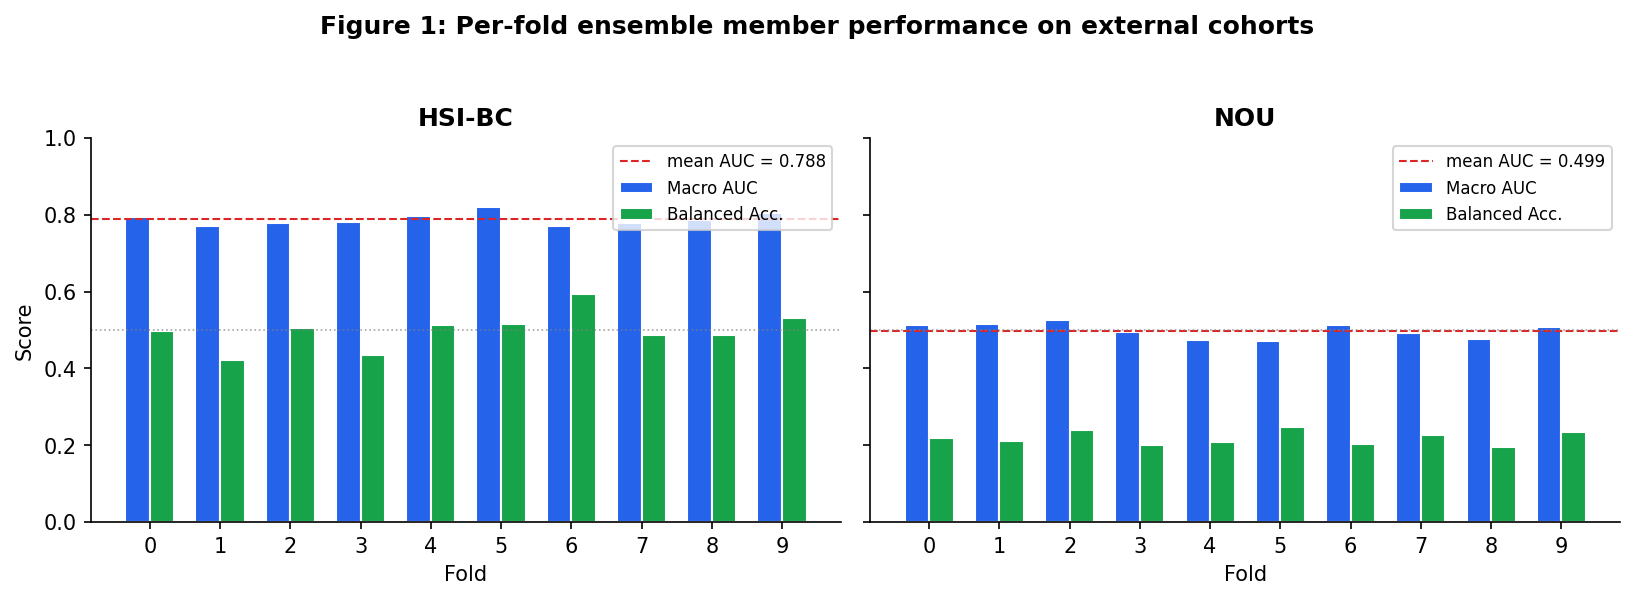

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, (tag, df) in zip(axes, fold_results.items()):
    folds = df.index.values
    width = 0.35
    ax.bar(folds - width/2, df["AUC"].values, width,
           label="Macro AUC", color="#2563EB", edgecolor="white")
    ax.bar(folds + width/2, df["BAcc"].values, width,
           label="Balanced Acc.", color="#16A34A", edgecolor="white")
    mean_auc = df["AUC"].mean()
    ax.axhline(mean_auc, color="#DC2626", ls="--", lw=1.0,
               label=f"mean AUC = {mean_auc:.3f}")
    ax.axhline(0.5, color="gray", ls=":", lw=0.8, alpha=0.7)
    ax.set_title(f"{tag}")
    ax.set_xlabel("Fold")
    ax.set_xticks(folds)
    ax.set_ylim([0.0, 1.0])
    ax.legend(fontsize=8, loc="upper right")
axes[0].set_ylabel("Score")
fig.suptitle("Figure 1: Per-fold ensemble member performance on external cohorts",
             fontweight="bold", y=1.04)
fig.tight_layout()
plt.show()

## Aggregated Ensemble Predictions (Slide-Level)

Mean-softmax ensemble of 10 fold-checkpoints. For HSI-BC, slide-level = patient-level (one WSI per patient). NOU patient-level aggregation follows below.

In [6]:
def compute_metrics(df, prob_cols=PROB_COLS):
    y = df["true_label"].values.astype(int)
    yp = df["pred_label"].values.astype(int)
    P = df[prob_cols].values.astype(float)
    yb = label_binarize(y, classes=list(range(N_CLASSES)))
    try:
        macro_auc = roc_auc_score(yb, P, multi_class="ovr", average="macro")
    except ValueError:
        macro_auc = float("nan")
    class_aucs = []
    for i in range(N_CLASSES):
        if yb[:, i].sum() > 0 and yb[:, i].sum() < len(y):
            class_aucs.append(roc_auc_score(yb[:, i], P[:, i]))
        else:
            class_aucs.append(float("nan"))
    report = classification_report(y, yp, target_names=CLASS_NAMES,
                                   output_dict=True, zero_division=0)
    return {
        "y": y, "yp": yp, "P": P, "yb": yb,
        "macro_auc": macro_auc,
        "class_aucs": class_aucs,
        "acc": (y == yp).mean(),
        "bacc": balanced_accuracy_score(y, yp),
        "wf1": report["weighted avg"]["f1-score"],
        "mf1": report["macro avg"]["f1-score"],
        "report": report,
    }

image_metrics = {tag: compute_metrics(df) for tag, df in datasets.items()}

print("Table 3: Aggregated ensemble metrics (slide-level)")
print("=" * 78)
header = f"  {'Cohort':<10s}  {'Macro AUC':>10s}  {'Acc':>8s}  {'BAcc':>8s}  {'Macro F1':>10s}  {'Wt. F1':>8s}"
print(header)
print("  " + "-" * 64)
for tag, m in image_metrics.items():
    print(f"  {tag:<10s}  {m['macro_auc']:>10.4f}  {m['acc']:>8.4f}  "
          f"{m['bacc']:>8.4f}  {m['mf1']:>10.4f}  {m['wf1']:>8.4f}")
print("=" * 78)
print()
print("Note: BAcc (balanced accuracy) is the macro-averaged recall and equals")
print("random-chance level (1/4 = 0.25) when the model collapses to a single class.")

Table 3: Aggregated ensemble metrics (slide-level)
  Cohort       Macro AUC       Acc      BAcc    Macro F1    Wt. F1
  ----------------------------------------------------------------
  HSI-BC          0.8042    0.4043    0.5315      0.3905    0.4004
  NOU             0.5028    0.5222    0.2215      0.2250    0.5600

Note: BAcc (balanced accuracy) is the macro-averaged recall and equals
random-chance level (1/4 = 0.25) when the model collapses to a single class.


In [7]:
for tag, m in image_metrics.items():
    print(f"Classification report -- {tag} (slide-level)")
    print("=" * 60)
    print(classification_report(m["y"], m["yp"],
                                target_names=CLASS_NAMES, zero_division=0))
    print()

Classification report -- HSI-BC (slide-level)
              precision    recall  f1-score   support

        LumA       0.33      0.60      0.43        10
        LumB       0.73      0.28      0.40        29
       Basal       0.50      0.25      0.33         4
        Her2       0.25      1.00      0.40         4

    accuracy                           0.40        47
   macro avg       0.45      0.53      0.39        47
weighted avg       0.58      0.40      0.40        47


Classification report -- NOU (slide-level)
              precision    recall  f1-score   support

        LumA       0.79      0.66      0.72       152
        LumB       0.08      0.13      0.10        23
       Basal       0.00      0.00      0.00         6
        Her2       0.07      0.09      0.08        22

    accuracy                           0.52       203
   macro avg       0.23      0.22      0.23       203
weighted avg       0.61      0.52      0.56       203




### Confusion matrices

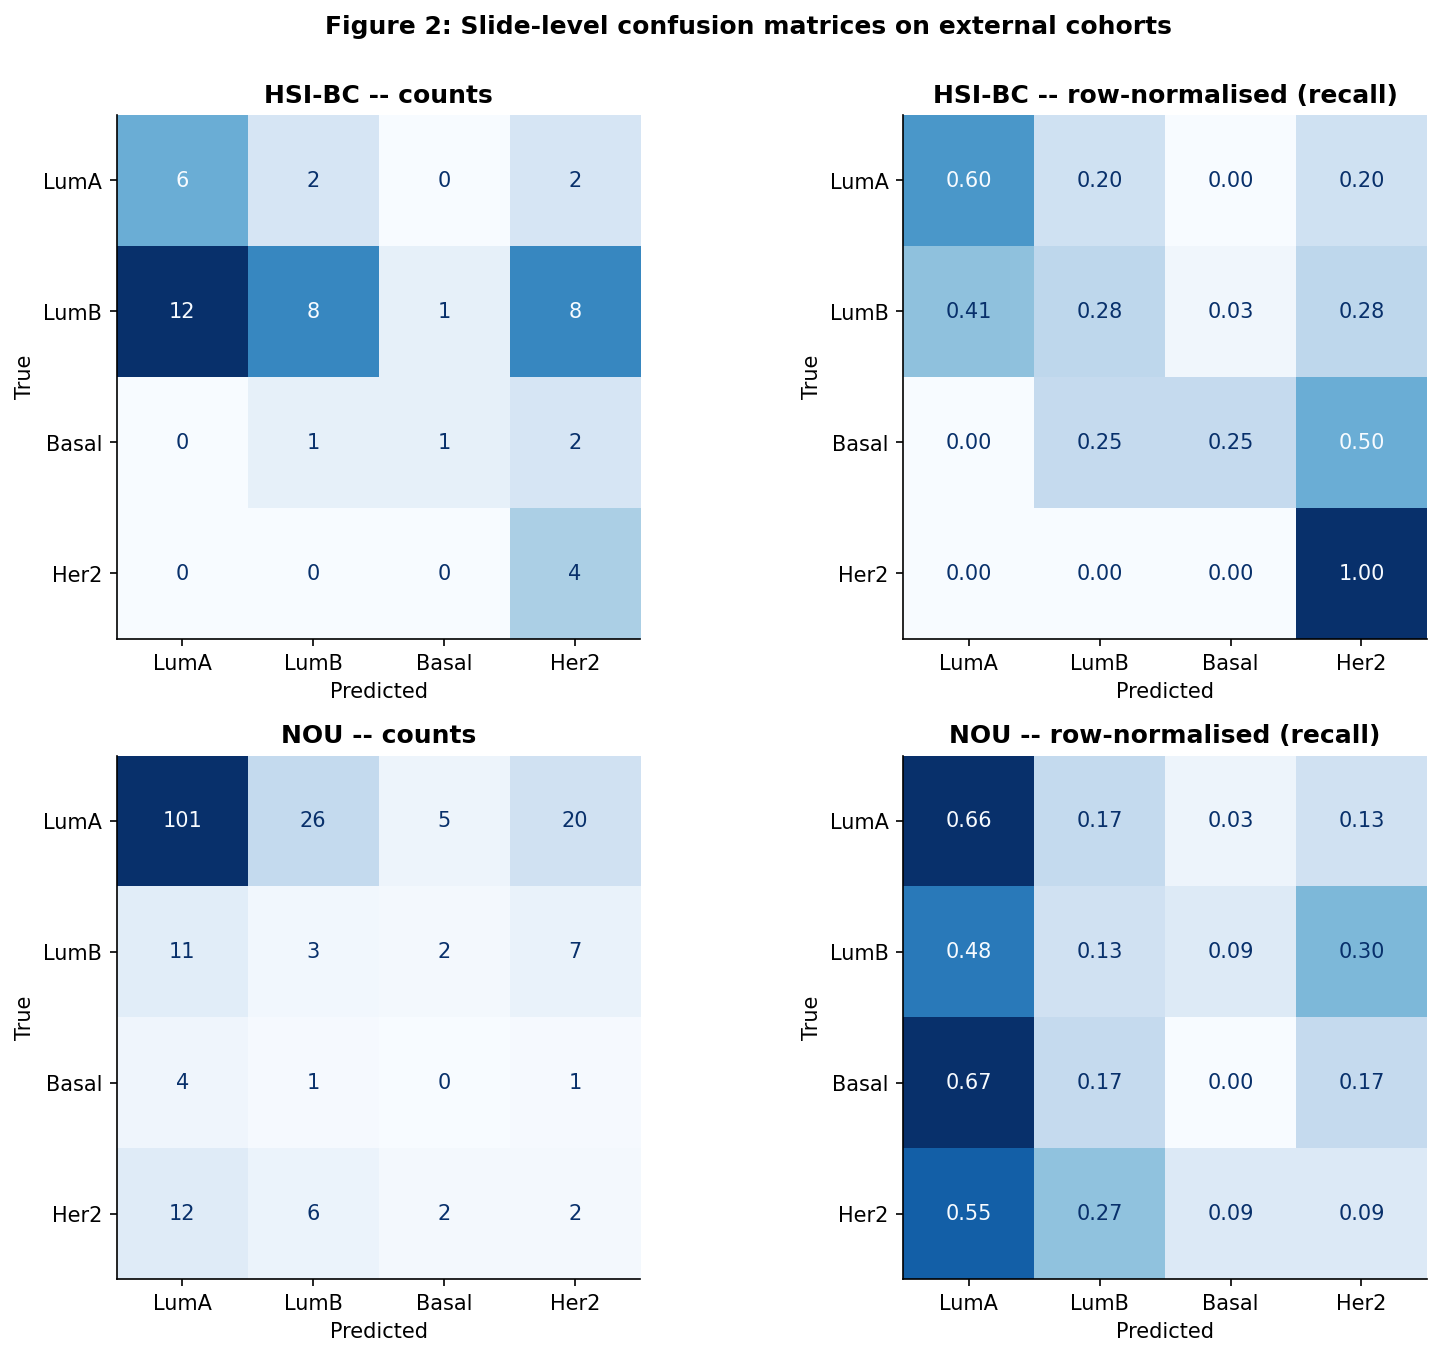

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for row, (tag, m) in enumerate(image_metrics.items()):
    cm_raw = confusion_matrix(m["y"], m["yp"], labels=list(range(N_CLASSES)))
    row_sums = cm_raw.sum(axis=1, keepdims=True).astype(float)
    row_sums[row_sums == 0] = 1
    cm_norm = cm_raw / row_sums

    ConfusionMatrixDisplay(cm_raw, display_labels=CLASS_NAMES).plot(
        ax=axes[row, 0], cmap="Blues", colorbar=False)
    axes[row, 0].set_title(f"{tag} -- counts")
    ConfusionMatrixDisplay(cm_norm, display_labels=CLASS_NAMES).plot(
        ax=axes[row, 1], cmap="Blues", colorbar=False, values_format=".2f")
    axes[row, 1].set_title(f"{tag} -- row-normalised (recall)")
    for a in axes[row]:
        a.set_xlabel("Predicted")
        a.set_ylabel("True")

fig.suptitle("Figure 2: Slide-level confusion matrices on external cohorts",
             fontweight="bold", y=1.00)
fig.tight_layout()
plt.show()

### ROC Curves (One-vs-Rest)

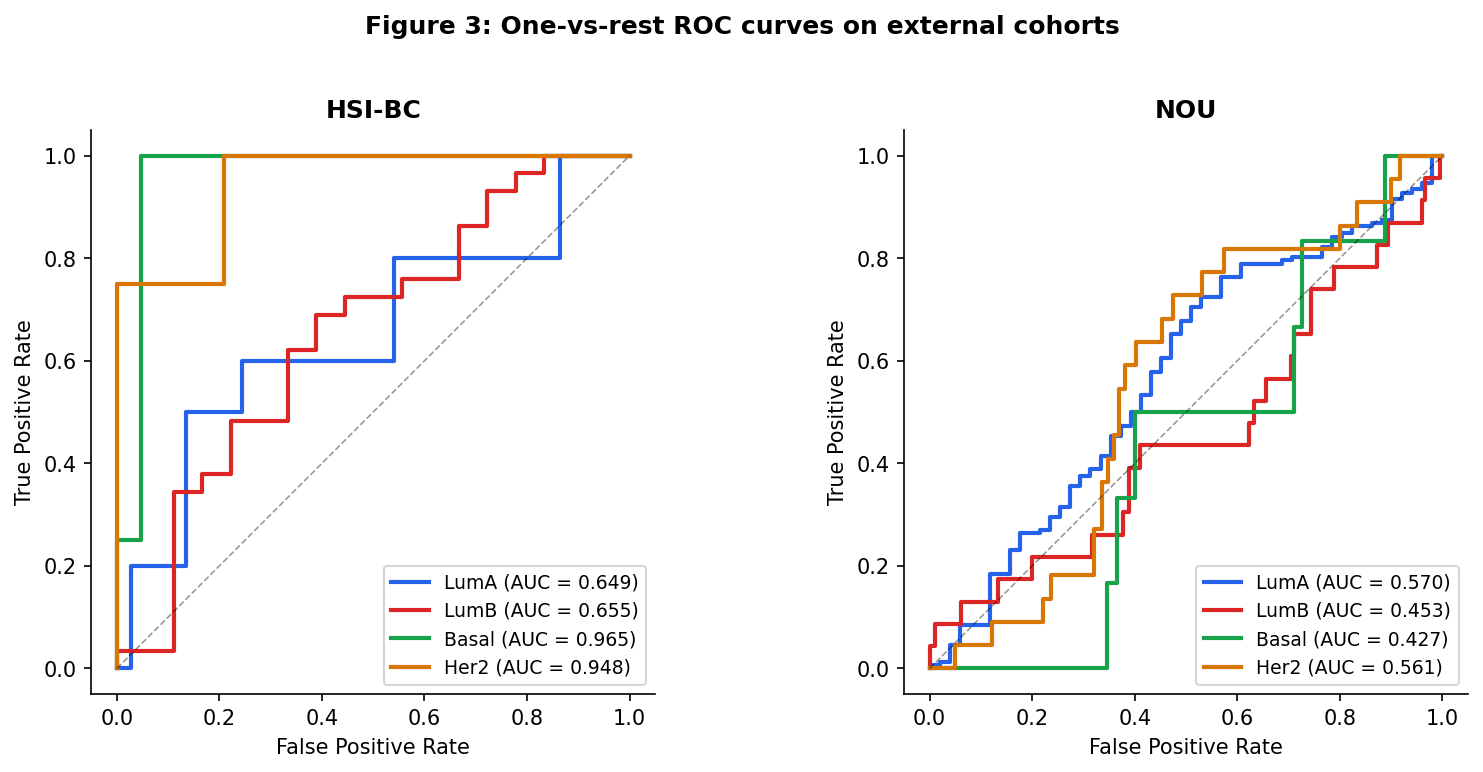

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (tag, m) in zip(axes, image_metrics.items()):
    for i, name in enumerate(CLASS_NAMES):
        if m["yb"][:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(m["yb"][:, i], m["P"][:, i])
        auc_val = calc_auc(fpr, tpr)
        ax.plot(fpr, tpr, color=CLASS_COLORS[name], lw=2,
                label=f"{name} (AUC = {auc_val:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.4)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{tag}")
    ax.legend(fontsize=9, loc="lower right")
    ax.set_aspect("equal")
fig.suptitle("Figure 3: One-vs-rest ROC curves on external cohorts",
             fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### Per-class breakdown

In [10]:
rows = []
for tag, m in image_metrics.items():
    for i, name in enumerate(CLASS_NAMES):
        r = m["report"][name]
        rows.append({
            "Cohort": tag,
            "Class": name,
            "Support": int(r["support"]),
            "AUC": m["class_aucs"][i],
            "Precision": r["precision"],
            "Recall": r["recall"],
            "F1": r["f1-score"],
        })
perclass_df = pd.DataFrame(rows)
print("Table 4: Per-class metrics on external cohorts (slide-level)")
print("=" * 78)
print(perclass_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("=" * 78)

Table 4: Per-class metrics on external cohorts (slide-level)
Cohort Class  Support    AUC  Precision  Recall     F1
HSI-BC  LumA       10 0.6486     0.3333  0.6000 0.4286
HSI-BC  LumB       29 0.6552     0.7273  0.2759 0.4000
HSI-BC Basal        4 0.9651     0.5000  0.2500 0.3333
HSI-BC  Her2        4 0.9477     0.2500  1.0000 0.4000
   NOU  LumA      152 0.5702     0.7891  0.6645 0.7214
   NOU  LumB       23 0.4529     0.0833  0.1304 0.1017
   NOU Basal        6 0.4272     0.0000  0.0000 0.0000
   NOU  Her2       22 0.5608     0.0667  0.0909 0.0769


## NOU Patient-Level Evaluation

We aggregate the ensemble softmax probabilities across all tissue blocks of a patient by averaging, then argmax for the patient-level prediction.

In [11]:
nou = datasets["NOU"]
patient_df = (nou.groupby("case_id")
                 .agg(true_label=("true_label", "first"),
                      true_name=("true_name", "first"),
                      p_LumA=("p_LumA", "mean"),
                      p_LumB=("p_LumB", "mean"),
                      p_Basal=("p_Basal", "mean"),
                      p_Her2=("p_Her2", "mean"),
                      n_blocks=("slide_id", "count"))
                 .reset_index())
patient_df["pred_label"] = patient_df[PROB_COLS].values.argmax(axis=1)
patient_df["pred_name"] = patient_df["pred_label"].map(dict(enumerate(CLASS_NAMES)))

patient_metrics_nou = compute_metrics(patient_df)

print(f"NOU patient-level evaluation: n = {len(patient_df)} patients, "
      f"median {patient_df['n_blocks'].median():.0f} blocks/patient")
print("=" * 60)
print(f"  Macro AUC:           {patient_metrics_nou['macro_auc']:.4f}")
print(f"  Accuracy:            {patient_metrics_nou['acc']:.4f}")
print(f"  Balanced accuracy:   {patient_metrics_nou['bacc']:.4f}")
print(f"  Macro F1:            {patient_metrics_nou['mf1']:.4f}")
print(f"  Weighted F1:         {patient_metrics_nou['wf1']:.4f}")
print()
print(classification_report(patient_metrics_nou["y"], patient_metrics_nou["yp"],
                            target_names=CLASS_NAMES, zero_division=0))

NOU patient-level evaluation: n = 28 patients, median 7 blocks/patient
  Macro AUC:           0.4246
  Accuracy:            0.7143
  Balanced accuracy:   0.2381
  Macro F1:            0.2128
  Weighted F1:         0.6383

              precision    recall  f1-score   support

        LumA       0.77      0.95      0.85        21
        LumB       0.00      0.00      0.00         3
       Basal       0.00      0.00      0.00         1
        Her2       0.00      0.00      0.00         3

    accuracy                           0.71        28
   macro avg       0.19      0.24      0.21        28
weighted avg       0.58      0.71      0.64        28



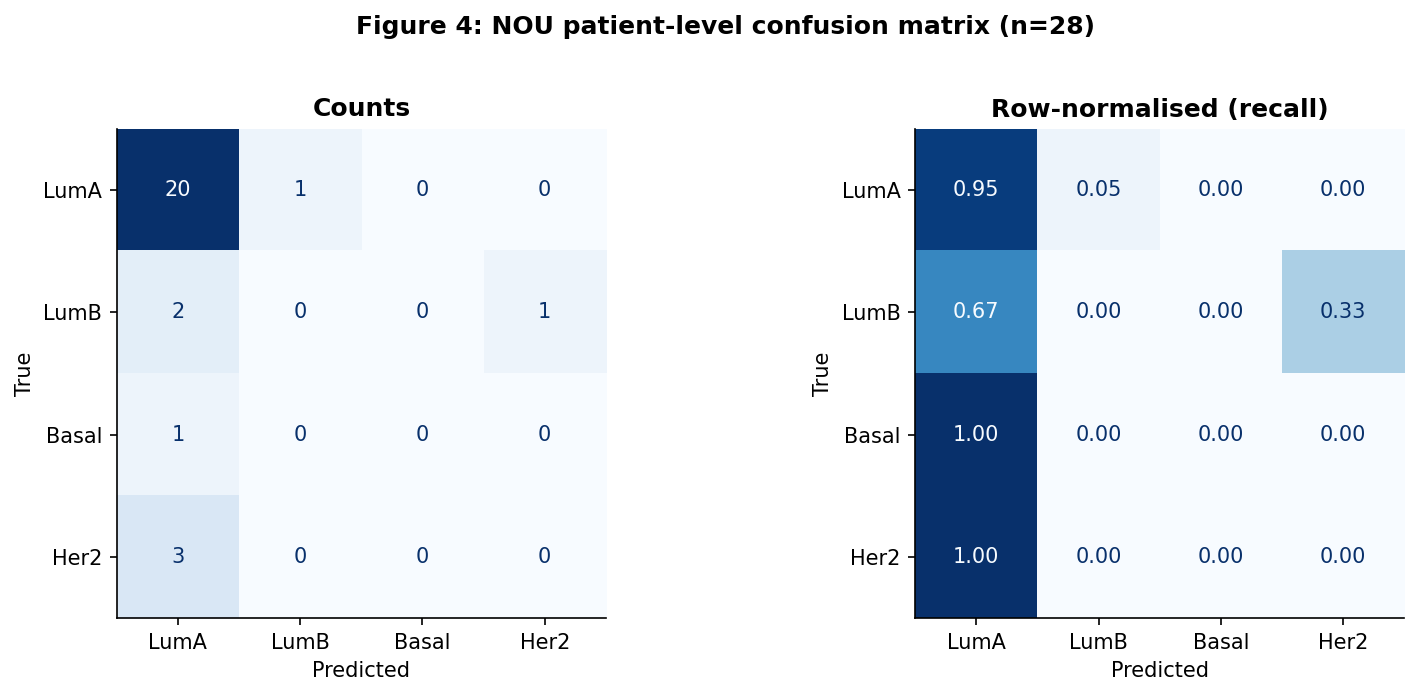

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
cm_raw = confusion_matrix(patient_metrics_nou["y"], patient_metrics_nou["yp"],
                          labels=list(range(N_CLASSES)))
row_sums = cm_raw.sum(axis=1, keepdims=True).astype(float)
row_sums[row_sums == 0] = 1
cm_norm = cm_raw / row_sums

ConfusionMatrixDisplay(cm_raw, display_labels=CLASS_NAMES).plot(
    ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Counts")
ConfusionMatrixDisplay(cm_norm, display_labels=CLASS_NAMES).plot(
    ax=axes[1], cmap="Blues", colorbar=False, values_format=".2f")
axes[1].set_title("Row-normalised (recall)")
for a in axes:
    a.set_xlabel("Predicted")
    a.set_ylabel("True")
fig.suptitle("Figure 4: NOU patient-level confusion matrix (n=28)",
             fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

## Comparison: Internal vs. External

In [13]:
tcga_summary = {
    "Macro AUC": 0.8879,
    "Accuracy": 0.7181,
    "Balanced Acc.": float("nan"),
    "Weighted F1": 0.7179,
    "LumA AUC": 0.8967,
    "LumB AUC": 0.8174,
    "Basal AUC": 0.9529,
    "Her2 AUC": 0.8846,
}

def to_row(m):
    return {
        "Macro AUC": m["macro_auc"],
        "Accuracy": m["acc"],
        "Balanced Acc.": m["bacc"],
        "Weighted F1": m["wf1"],
        "LumA AUC": m["class_aucs"][0],
        "LumB AUC": m["class_aucs"][1],
        "Basal AUC": m["class_aucs"][2],
        "Her2 AUC": m["class_aucs"][3],
    }

comp = pd.DataFrame({
    "TCGA-BRCA (10-fold CV)": tcga_summary,
    "HSI-BC (slide=patient)": to_row(image_metrics["HSI-BC"]),
    "NOU (slide-level)": to_row(image_metrics["NOU"]),
    "NOU (patient-level)": to_row(patient_metrics_nou),
})

print("Table 5: TCGA-BRCA internal vs. HSI-BC and NOU external")
print("=" * 90)
print(comp.to_string(float_format=lambda x: "  -- " if pd.isna(x) else f"{x:.4f}"))
print("=" * 90)
print()
print("TCGA values are reproduced from evaluate_pam50.pdf (10-fold CV, aggregated test set).")

Table 5: TCGA-BRCA internal vs. HSI-BC and NOU external
               TCGA-BRCA (10-fold CV)  HSI-BC (slide=patient)  NOU (slide-level)  NOU (patient-level)
Macro AUC                      0.8879                  0.8042             0.5028               0.4246
Accuracy                       0.7181                  0.4043             0.5222               0.7143
Balanced Acc.                     NaN                  0.5315             0.2215               0.2381
Weighted F1                    0.7179                  0.4004             0.5600               0.6383
LumA AUC                       0.8967                  0.6486             0.5702               0.6599
LumB AUC                       0.8174                  0.6552             0.4529               0.4667
Basal AUC                      0.9529                  0.9651             0.4272               0.1852
Her2 AUC                       0.8846                  0.9477             0.5608               0.3867

TCGA values are reproduce

## Findings

1. **HSI-BC: useful transfer, substantial drop.** Macro AUC drops from 0.888 (TCGA internal) to **0.804** (~9 pp). Per-class AUC ranking preserved (Basal, Her2, LumA, LumB). Low accuracy (0.40) reflects LumB dominance (62% of cohort) -- the model frequently confuses LumB with LumA.

2. **NOU: model collapses to chance.** Slide-level macro AUC = 0.50, patient-level = 0.42. The 71% patient-level accuracy is misleading -- it merely reflects LumA prevalence (75%). Balanced accuracy is ~0.24, i.e. random. All 10 ensemble members produce AUC in [0.47, 0.53], confirming systematic failure.

3. **NOU collapse is likely a domain shift issue.** NOU TIFFs are small tissue crops (~210 patches/slide vs. ~48k for HSI-BC). CLAM attention, trained on large bags, cannot extract signal from bags two orders of magnitude smaller.

4. **Class imbalance amplifies AUC--accuracy gap.** Both cohorts are heavily luminal-skewed (HSI-BC 83%, NOU 89%), with 4 or fewer Basal/Her2 patients each. Per-class metrics have wide uncertainty at these sample sizes.

5. **IHC-to-PAM50 label noise caps performance.** Both cohorts use IHC surrogates (~80% concordance with genomic PAM50), so some "errors" are label-definition disagreements.

## Next Steps

1. **Re-patch NOU** with a patching strategy that matches the TCGA training distribution (larger bags, proper field-of-view alignment).
2. **Stain normalisation** (Macenko/Vahadane) before feature extraction to reduce domain shift.
3. **Bootstrap confidence intervals** (stratified, 1000 resamples) for all headline metrics.
4. **Light fine-tuning** of CLAM-MB on external data to distinguish feature-level vs. aggregator-level failure.
5. **Multimodal fusion** using clinico-pathological features (HSI-BC clinical data, NOU CTC EP/EMT counts) alongside WSI embeddings.

## Summary

In [14]:
print("=" * 70)
print("  CLAM-MB + UNI2-h | PAM50 Subtyping | External Validation")
print("  Model: 10x checkpoints from TCGA-BRCA (no retraining)")
print("=" * 70)
print()
print("--- TCGA-BRCA (internal benchmark from evaluate_pam50.pdf) ---")
for k, v in tcga_summary.items():
    if pd.isna(v):
        continue
    print(f"  {k:<14s}  {v:.4f}")
print()
for tag, m in image_metrics.items():
    print(f"--- {tag} (slide-level, n = {len(datasets[tag])}) ---")
    print(f"  Macro AUC      {m['macro_auc']:.4f}")
    print(f"  Accuracy       {m['acc']:.4f}")
    print(f"  Balanced Acc.  {m['bacc']:.4f}")
    print(f"  Weighted F1    {m['wf1']:.4f}")
    print()
print(f"--- NOU (patient-level, n = {len(patient_df)}) ---")
print(f"  Macro AUC      {patient_metrics_nou['macro_auc']:.4f}")
print(f"  Accuracy       {patient_metrics_nou['acc']:.4f}")
print(f"  Balanced Acc.  {patient_metrics_nou['bacc']:.4f}")
print(f"  Weighted F1    {patient_metrics_nou['wf1']:.4f}")
print("=" * 70)

  CLAM-MB + UNI2-h | PAM50 Subtyping | External Validation
  Model: 10x checkpoints from TCGA-BRCA (no retraining)

--- TCGA-BRCA (internal benchmark from evaluate_pam50.pdf) ---
  Macro AUC       0.8879
  Accuracy        0.7181
  Weighted F1     0.7179
  LumA AUC        0.8967
  LumB AUC        0.8174
  Basal AUC       0.9529
  Her2 AUC        0.8846

--- HSI-BC (slide-level, n = 47) ---
  Macro AUC      0.8042
  Accuracy       0.4043
  Balanced Acc.  0.5315
  Weighted F1    0.4004

--- NOU (slide-level, n = 203) ---
  Macro AUC      0.5028
  Accuracy       0.5222
  Balanced Acc.  0.2215
  Weighted F1    0.5600

--- NOU (patient-level, n = 28) ---
  Macro AUC      0.4246
  Accuracy       0.7143
  Balanced Acc.  0.2381
  Weighted F1    0.6383
